#### Dependencies

In [1]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats as scipy_stats

##### Read in the data

In [2]:
# read in the data
hmda_all = pd.read_csv('../data/hmda_all.csv') 
hmda_all_nf = pd.read_csv('../data/hmda_all_nf.csv')

C:\Users\Cat\AppData\Local\Temp\ipykernel_26828\871124796.py:3: DtypeWarning: Columns (26,27,28,29,30,31,32,33,43,44,78,80) have mixed types. Specify dtype option on import or set low_memory=False.
  hmda_all_nf = pd.read_csv('../data/hmda_all_nf.csv')


In [3]:
# Filter to Black or African American applicants
black_df = hmda_all_nf[hmda_all_nf['ar_values_3'] == 1].copy()

# Filter to White applicants
white_df = hmda_all_nf[hmda_all_nf['ar_values_5'] == 1].copy()

print(f"Black applicants:  {len(black_df):,}")
print(f"White applicants:  {len(white_df):,}")
print(f"\nOverall raw approval rates:")
print(f"  Black applicants: {black_df['approved_originated_or_denied'].mean():.1%}")
print(f"  White applicants: {white_df['approved_originated_or_denied'].mean():.1%}")

Black applicants:  247,335
White applicants:  401,667

Overall raw approval rates:
  Black applicants: 69.0%
  White applicants: 83.0%


### Lender Chart with Raw approval Rates

In [4]:
def approval_rate_with_ci(x, alpha=0.05):
    n  = len(x)
    p  = x.mean()
    z  = scipy_stats.norm.ppf(1 - alpha / 2)
    se = np.sqrt(p * (1 - p) / n)
    return pd.Series({
        'approval_rate':  p,
        'ci_lower':       max(0, p - z * se),
        'ci_upper':       min(1, p + z * se),
        'n_applications': n,
    })

min_apps = 50

# Raw approval rates by lender for Black applicants
lender_black = (
    black_df.groupby('lei')['approved_originated_or_denied']
    .apply(approval_rate_with_ci)
    .unstack()
    .reset_index()
)
lender_black.columns = ['lei', 'approval_rate_black', 'ci_lower_black', 'ci_upper_black', 'n_black']
lender_black = lender_black[lender_black['n_black'] >= min_apps]

# Raw approval rates by lender for White applicants
lender_white = (
    white_df.groupby('lei')['approved_originated_or_denied']
    .apply(approval_rate_with_ci)
    .unstack()
    .reset_index()
)
lender_white.columns = ['lei', 'approval_rate_white', 'ci_lower_white', 'ci_upper_white', 'n_white']

# Merge and calculate gap
lender_combined = lender_black.merge(lender_white, on='lei', how='left')
lender_combined['gap'] = lender_combined['approval_rate_white'] - lender_combined['approval_rate_black']
lender_combined = lender_combined.sort_values('approval_rate_black', ascending=True)

print(f"Lenders with at least {min_apps} Black applications: {len(lender_combined)}")
print(f"\nOverall raw approval rates:")
print(f"  Black applicants: {black_df['approved_originated_or_denied'].mean():.1%}")
print(f"  White applicants: {white_df['approved_originated_or_denied'].mean():.1%}")
print(f"\nBottom 10 lenders:")
print(lender_combined.head(10)[['lei', 'approval_rate_black', 'approval_rate_white', 'gap', 'n_black']].to_string(index=False))

Lenders with at least 50 Black applications: 271

Overall raw approval rates:
  Black applicants: 69.0%
  White applicants: 83.0%

Bottom 10 lenders:
                 lei  approval_rate_black  approval_rate_white       gap  n_black
5493000WAJ1FMTFL5D75             0.089286             0.267857  0.178571    112.0
549300IX6RAX31C1BI75             0.125000             0.269231  0.144231     56.0
549300XQVJ1XBNFA5536             0.155028             0.212427  0.057399    716.0
X05BVSK68TQ7YTOSNR22             0.190889             0.297525  0.106636   3117.0
549300ALNLUNS3Y53T24             0.208378             0.419034  0.210656   3724.0
549300CB67L6KPJLHE19             0.214092             0.213849 -0.000243    369.0
549300NOCASXPA34X033             0.248691             0.647186  0.398495    382.0
549300SUCQ1358EGVE89             0.262387             0.378601  0.116213   1776.0
549300RM1IZYGQDSNL85             0.285714             0.421053  0.135338     70.0
549300PIL8LFAQ04XC20          

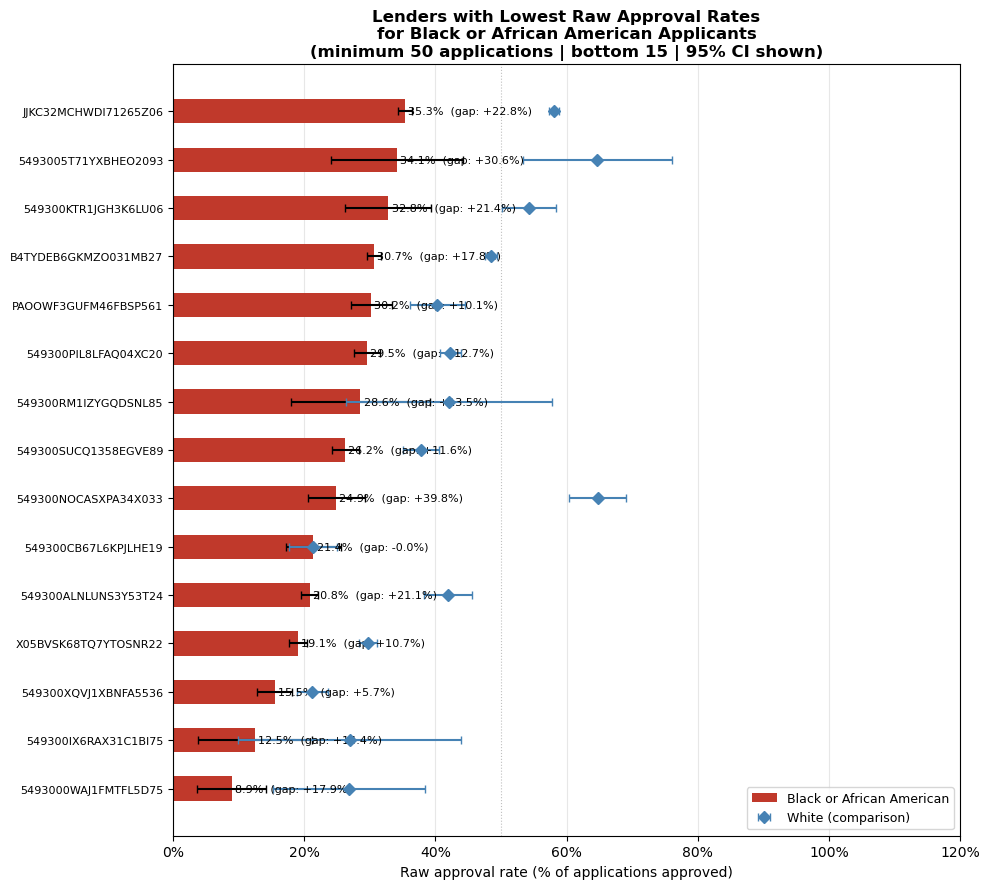

In [5]:
# Plot
top_n          = 15
bottom_lenders = lender_combined.head(top_n)

fig, ax = plt.subplots(figsize=(10, max(5, int(top_n * 0.5 + 2))))
y_pos = range(len(bottom_lenders))

ax.barh(
    y_pos,
    bottom_lenders['approval_rate_black'],
    xerr=[
        bottom_lenders['approval_rate_black'] - bottom_lenders['ci_lower_black'],
        bottom_lenders['ci_upper_black']       - bottom_lenders['approval_rate_black'],
    ],
    color='#c0392b', height=0.5, capsize=3,
    label='Black or African American', zorder=2
)

# ax.scatter(
#     bottom_lenders['approval_rate_white'], y_pos,
#     color='steelblue', zorder=3, s=60,
#     label='White (comparison)', marker='D'
# )

ax.errorbar(
    bottom_lenders['approval_rate_white'], y_pos,
    xerr=[
        bottom_lenders['approval_rate_white'] - bottom_lenders['ci_lower_white'],
        bottom_lenders['ci_upper_white']       - bottom_lenders['approval_rate_white'],
    ],
    fmt='D', color='steelblue', markersize=6, capsize=3,
    linewidth=1.5, label='White (comparison)', zorder=3
)

for i, (_, row) in enumerate(bottom_lenders.iterrows()):
    ax.text(
        row['approval_rate_black'] + 0.005, i,
        f"{row['approval_rate_black']:.1%}  (gap: {row['gap']:+.1%})",
        va='center', fontsize=8
    )

ax.set_yticks(list(y_pos))
ax.set_yticklabels(bottom_lenders['lei'], fontsize=8)
ax.set_xlabel('Raw approval rate (% of applications approved)')
ax.set_xlim(0, 1.2)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title(
    f'Lenders with Lowest Raw Approval Rates\n'
    f'for Black or African American Applicants\n'
    f'(minimum {min_apps} applications | bottom {top_n} | 95% CI shown)',
    fontweight='bold'
)
ax.axvline(0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/lender_raw_approval_rate_black_applicants.png', bbox_inches='tight', dpi=150)
plt.show()

### AUS (Automated Underwriting System) Chart with Raw approval Rates

In [6]:
aus_labels_map = {
    1: "Desktop Underwriter (DU/DO)",
    2: "Loan Prospector / Loan Product Advisor (LP/LPA)",
    3: "Technology Open to Approved Lenders (TOTAL)",
    4: "Guaranteed Underwriting System (GUS)",
    5: "Other",
    7: "Internal Proprietary System",
}

aus_cols = ['aus-1', 'aus-2', 'aus-3', 'aus-4', 'aus-5']

def melt_aus(df):
    melted = df[['approved_originated_or_denied'] + aus_cols].melt(
        id_vars=['approved_originated_or_denied'],
        value_vars=aus_cols,
        var_name='aus_col',
        value_name='aus_code'
    )
    melted = melted.dropna(subset=['aus_code'])
    melted['aus_code'] = pd.to_numeric(melted['aus_code'], errors='coerce')
    melted = melted[~melted['aus_code'].isin([6, 1111])]
    melted = melted.dropna(subset=['aus_code'])
    melted['aus_code'] = melted['aus_code'].astype(int)
    return melted

aus_black_melted = melt_aus(black_df)
aus_white_melted = melt_aus(white_df)

# Raw approval rates by AUS for Black applicants
aus_black_stats = (
    aus_black_melted.groupby('aus_code')['approved_originated_or_denied']
    .apply(approval_rate_with_ci)
    .unstack()
    .reset_index()
)
aus_black_stats.columns = ['aus_code', 'approval_rate_black', 'ci_lower_black', 'ci_upper_black', 'n_black']

# Raw approval rates by AUS for White applicants
aus_white_stats = (
    aus_white_melted.groupby('aus_code')['approved_originated_or_denied']
    .apply(approval_rate_with_ci)
    .unstack()
    .reset_index()
)
aus_white_stats.columns = ['aus_code', 'approval_rate_white', 'ci_lower_white', 'ci_upper_white', 'n_white']

# Merge and calculate gap
aus_combined = aus_black_stats.merge(aus_white_stats, on='aus_code', how='left')
aus_combined['aus_name'] = aus_combined['aus_code'].map(aus_labels_map).fillna(aus_combined['aus_code'].astype(str))
aus_combined['gap'] = aus_combined['approval_rate_white'] - aus_combined['approval_rate_black']
aus_combined = aus_combined[aus_combined['n_black'] >= 20]
aus_combined = aus_combined.sort_values('approval_rate_black', ascending=True)

print("AUS Raw Approval Rates — Black vs. White Applicants:")
print(aus_combined[['aus_name', 'approval_rate_black', 'approval_rate_white', 'gap', 'n_black']].to_string(index=False))

AUS Raw Approval Rates — Black vs. White Applicants:
                                       aus_name  approval_rate_black  approval_rate_white      gap  n_black
                    Internal Proprietary System             0.344637             0.549000 0.204363   3627.0
                                          Other             0.556359             0.740054 0.183695   9821.0
    Technology Open to Approved Lenders (TOTAL)             0.762768             0.842446 0.079678  39042.0
Loan Prospector / Loan Product Advisor (LP/LPA)             0.778580             0.898875 0.120295  41988.0
                    Desktop Underwriter (DU/DO)             0.811978             0.915901 0.103923 113742.0
           Guaranteed Underwriting System (GUS)             0.847222             0.942418 0.095196    504.0


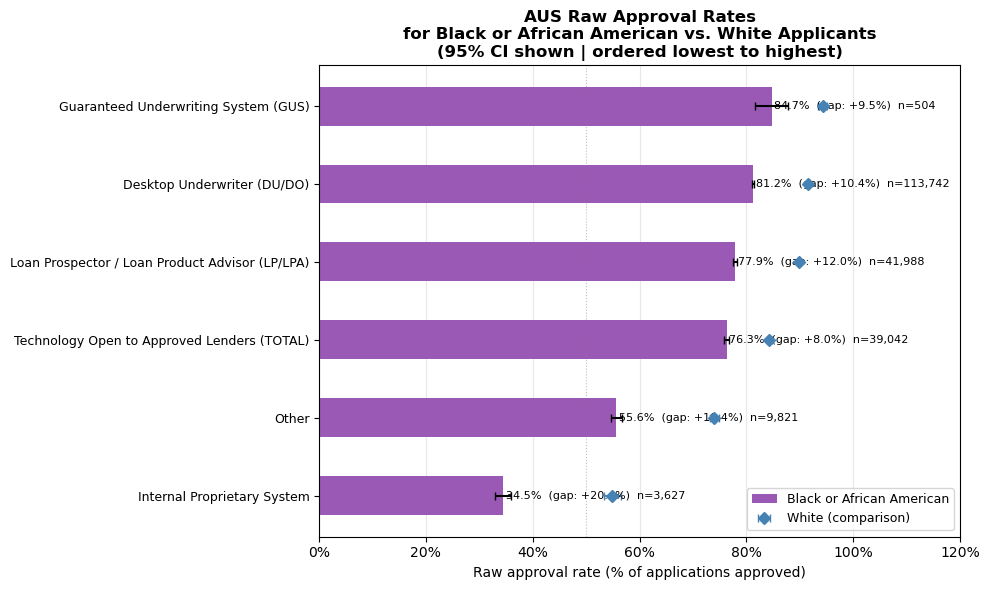


Key finding:
Highest approval rate: 84.7% — Guaranteed Underwriting System (GUS) (n=504)
Lowest approval rate:  34.5% — Internal Proprietary System (n=3,627)
Gap between best and worst AUS: 50.3%


In [7]:
fig, ax = plt.subplots(figsize=(10, max(4, int(len(aus_combined) * 0.8 + 1.5))))
y_pos = range(len(aus_combined))

ax.barh(
    y_pos,
    aus_combined['approval_rate_black'],
    xerr=[
        aus_combined['approval_rate_black'] - aus_combined['ci_lower_black'],
        aus_combined['ci_upper_black']      - aus_combined['approval_rate_black'],
    ],
    color='#9b59b6', height=0.5, capsize=3,
    label='Black or African American', zorder=2
)

# ax.scatter(
#     aus_combined['approval_rate_white'], y_pos,
#     color='steelblue', zorder=3, s=80,
#     label='White (comparison)', marker='D'
# )

ax.errorbar(
    aus_combined['approval_rate_white'], y_pos,
    xerr=[
        aus_combined['approval_rate_white'] - aus_combined['ci_lower_white'],
        aus_combined['ci_upper_white']       - aus_combined['approval_rate_white'],
    ],
    fmt='D', color='steelblue', markersize=6, capsize=3,
    linewidth=1.5, label='White (comparison)', zorder=3
)


for i, (_, row) in enumerate(aus_combined.iterrows()):
    ax.text(
        row['approval_rate_black'] + 0.005, i,
        f"{row['approval_rate_black']:.1%}  (gap: {row['gap']:+.1%})  n={int(row['n_black']):,}",
        va='center', fontsize=8
    )

ax.set_yticks(list(y_pos))
ax.set_yticklabels(aus_combined['aus_name'], fontsize=9)
ax.set_xlabel('Raw approval rate (% of applications approved)')
ax.set_xlim(0, 1.2)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title(
    'AUS Raw Approval Rates\n'
    'for Black or African American vs. White Applicants\n'
    '(95% CI shown | ordered lowest to highest)',
    fontweight='bold'
)
ax.axvline(0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/aus_raw_approval_rate_black_applicants.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\nKey finding:")
print(f"Highest approval rate: {aus_combined.iloc[-1]['approval_rate_black']:.1%} — {aus_combined.iloc[-1]['aus_name']} (n={int(aus_combined.iloc[-1]['n_black']):,})")
print(f"Lowest approval rate:  {aus_combined.iloc[0]['approval_rate_black']:.1%} — {aus_combined.iloc[0]['aus_name']} (n={int(aus_combined.iloc[0]['n_black']):,})")
print(f"Gap between best and worst AUS: {aus_combined.iloc[-1]['approval_rate_black'] - aus_combined.iloc[0]['approval_rate_black']:.1%}")